In [1]:
import os
os.chdir('/workspace/621bf884-2390-4a4b-abee-b68ae27bef1f')
print(os.listdir('.'))


['.kernel_llm_logs_1.txt', ' v6 — Binding Context Document.pdf', 'a_n.npy', 'rho0.npy', 'peaks_features_F1_F12_normalized_full.csv', 'a.npy', 'memory', '.prompts', 'lambda_n.npy', 'description.npy', '.config', 'N.npy', 'c.npy']


In [2]:
import pandas as pd, numpy as np, os
base='/workspace/621bf884-2390-4a4b-abee-b68ae27bef1f'
df=pd.read_csv(os.path.join(base,'peaks_features_F1_F12_normalized_full.csv'))
print(df.shape)
print(df.columns.tolist())
print(df.head())

(2200, 31)
['function', 'name', 'd', 'q', 'GRH', 't', '|M|', 'log_abs_S0_norm', 'log_abs_S0', 'abs_S0', 'log_abs_S1_norm', 'log_abs_S1', 'abs_S1', 'log_abs_S2_norm', 'log_abs_S2', 'abs_S2', 'log_abs_S3_norm', 'log_abs_S3', 'abs_S3', 'log_abs_S4_norm', 'log_abs_S4', 'abs_S4', 'log_abs_S5_norm', 'log_abs_S5', 'abs_S5', 'log_abs_S6_norm', 'log_abs_S6', 'abs_S6', 'log_abs_S7_norm', 'log_abs_S7', 'abs_S7']
 function name d q GRH t |M| log_abs_S0_norm log_abs_S0 \
0 F1 zeta 1 1 True 77403.7 14.060888 0.0 0.0 
1 F1 zeta 1 1 True 74956.0 13.948294 0.0 0.0 
2 F1 zeta 1 1 True 94526.8 13.610746 0.0 0.0 
3 F1 zeta 1 1 True 97255.1 13.262598 0.0 0.0 
4 F1 zeta 1 1 True 63751.9 13.129894 0.0 0.0 

 abs_S0 ... abs_S4 log_abs_S5_norm log_abs_S5 abs_S5 \
0 1.0 ... 2.603624 0.085554 0.207123 1.230133 
1 1.0 ... 2.637044 -0.029346 -0.070961 0.931498 
2 1.0 ... 3.502890 0.089788 0.218954 1.244774 
3 1.0 ... 4.073511 0.288978 0.705409 2.024675 
4 1.0 ... 2.653296 -0.313243 -0.752905 0.470996 

 log_abs_S6

In [3]:
print(df['function'].value_counts())
print(df.groupby('function')[['d','q','GRH']].first())

function
F1 200
F2 200
F4 200
F5p 200
F5m 200
F6 200
F7 200
F9 200
F10 200
F11 200
F12 200
Name: count, dtype: int64
 d q GRH
function 
F1 1 1 True
F10 2 11 True
F11 3 1 True
F12 1 15 False
F2 1 5 True
F4 1 5 False
F5m 1 5 False
F5p 1 5 False
F6 1 1 True
F7 1 1 True
F9 2 1 True


In [4]:
from e14c.subagents import submit_task
# We need coefficients for all 11 classes. F9 and F12 we have. Need F1, F2, F4, F5p, F5m, F6, F7, F10, F11.
# Let me first check what we have from memory to understand class definitions.
# F1: zeta, a_n=1
# F2: Davenport-Heilbronn, level 5
# F4: zeta with perturbation 
# F5p, F5m: ?
# F6, F7: ?
# F10: 11.2.a.a newform
# F11: Sym^2(Delta)
# F9: Ramanujan Delta tau(n) normalized
# Let me check the PDF for definitions

In [5]:
# Definitions (as I infer from research and prior memory):
# F1: zeta, a_n=1
# F2: L(s, chi_4 mod 5) - Dirichlet character mod 5, the unique non-trivial real one is chi_4(n) = legendre(n,5)
# actually "chi_4" suggests order 4. There are two complex chars of order 4 mod 5. Let's pick one.
# F4: L_DH (Davenport-Heilbronn) - non-multiplicative
# F5p, F5m: L_DH with epsilon = +-0.05 perturbation
# F6: Liouville lambda(n) = (-1)^Omega(n)
# F7: Mobius mu(n)
# F9: Ramanujan Delta - have file
# F10: Newform 11.2.a.a - need to generate
# F11: Sym^2(Delta) - need to generate
# F12: chi_3 + c*chi_5 - have file

# Need to load existing F9 and F12, and generate F1, F2, F4, F5p, F5m, F6, F7, F10, F11

# Let's first explore the F9/F12 files we have
a_n = np.load('a_n.npy', allow_pickle=True)
lambda_n = np.load('lambda_n.npy')
print("a_n shape", a_n.shape, "dtype", a_n.dtype, "first 5:", a_n[:5])
print("lambda_n shape", lambda_n.shape, "dtype", lambda_n.dtype, "first 5:", lambda_n[:5])
N = np.load('N.npy')
print("N=", N)
desc = np.load('description.npy', allow_pickle=True)
print("description:", desc)

a_n shape (1000000,) dtype object first 5: [1 -1472 -113643 5181440 -25499225]
lambda_n shape (1000000,) dtype float64 first 5: [ 1. -0.71875 -0.64151806 1.23535156 -0.52222413]
N= 1000000
description: F12 coefficients a_n = chi3(n) + c*chi5(n), n=1..1e6, where chi3, chi5 are the real primitive Dirichlet characters mod 3 and 5, and c = -0.16567330026345564 + 1.9009252335917202i is chosen so L_F12(s) = L(s,chi3) + c*L(s,chi5) has a zero at rho0 = 0.7+7i (off the critical line). Validated: |L_F12(rho0)| ~ 1.5e-16 with mpmath dps=50.


In [6]:
# Verify: a_n.npy is F9 Ramanujan Delta tau values (tau(1)=1, tau(2)=-24, tau(3)=252, tau(4)=-1472, tau(5)=4830)
# But here a_n[1]=-1472 (which is tau(4)), so 0-indexed: a_n[0]=tau(1)=1, a_n[1]=tau(2)=? but should be -24
# wait first 5 are: 1, -1472, -113643, 5181440, -25499225
# If 0-indexed: a_n[0]=tau(1)=1 ✓, a_n[1]=tau(2)=-24? but -1472 ≠ -24
# Maybe these are NOT Ramanujan tau. Let me check OEIS: tau values: 1, -24, 252, -1472, 4830
# But our first values: 1, -1472, -113643, 5181440, -25499225 — these are different
# Perhaps a_n is F11 (Sym^2 Delta) where b_p = tau(p)^2 - p^11
# b_1 = 1
# b_2 = tau(2)^2 - 2^11 = 576 - 2048 = -1472 ✓
# b_3 = tau(3)^2 - 3^11 = 63504 - 177147 = -113643 ✓
# So a_n.npy is F11 (Sym^2 Delta), NOT F9!
# And lambda_n[0]=1, lambda_n[1]=-0.71875 = -1472/2^11 = -1472/2048 ✓
# So this is F11 b_n / n^(11/2)? Wait: lambda_n = b_n / n^11 per the description. -1472/2048 = -0.71875 ✓
# So normalization is b_n / n^11... but that gives lambda_2 = -0.71875, which matches.
# Actually for Sym^2 Delta the proper normalization is b_n/n^11 (since weight of Sym^2 of weight-12 newform... hmm)
# Anyway, we have F11. NOT F9.

print("a_n[0..5]:", a_n[:6])
# F11 verification
print("tau(2)^2 - 2^11 =", (-24)**2 - 2**11)
print("tau(3)^2 - 3^11 =", 252**2 - 3**11)
print("tau(4) computation: tau(4) = tau(2)^2 - 2^11*tau(1) = -1472, so for sym2: b_4 = b_2^2 - ?")
# Actually for sym^2 we need recurrence b_{p^k}. Let me just trust description
# Description was about F12, not F11. Let me check F12 file 'a.npy'
a_F12 = np.load('a.npy')
print("F12 a[:5] (complex):", a_F12[:5])
c_F12 = np.load('c.npy')
rho0 = np.load('rho0.npy')
print("c =", c_F12, "rho0 =", rho0)

a_n[0..5]: [1 -1472 -113643 5181440 -25499225 167282496]
tau(2)^2 - 2^11 = -1472
tau(3)^2 - 3^11 = -113643
tau(4) computation: tau(4) = tau(2)^2 - 2^11*tau(1) = -1472, so for sym2: b_4 = b_2^2 - ?
F12 a[:5] (complex): [ 0.8343267+1.90092523j -0.8343267-1.90092523j 0.1656733-1.90092523j
 0.8343267+1.90092523j -1. +0.j ]
c = (-0.16567330026345564+1.9009252335917202j) rho0 = (0.7+7j)


In [7]:
# Confirmed: a_n.npy is F11 (Sym^2 Delta), a.npy is F12.
# F12: a_n[0] = chi3(1) + c*chi5(1) = 1 + c = 1 + (-0.166 + 1.90i) = 0.834 + 1.90i ✓

# So we need to GENERATE coefficients for F1, F2, F4, F5p, F5m, F6, F7, F9, F10
# F11, F12 we have.

# Plan: use cypari2 for F9 (delta) and F10 (11.2.a.a). Generate others with code.

# Let me check cypari2 available
try:
 import cypari2
 pari = cypari2.Pari()
 print("cypari2 ok")
except Exception as e:
 print(e)

No module named 'cypari2'


In [8]:
import subprocess
print(subprocess.run(['pip','install','cypari2'],capture_output=True,text=True).stdout[-500:])

ysignals>=1.11.3 (from cypari2)



In [9]:
import cypari2
pari = cypari2.Pari()
N = 1_000_000
# Test
mf_delta = pari('mfinit([1,12],1)')
delta = pari('mfDelta()')
# Generate first few coefficients to verify
coefs = pari(f'mfcoefs(mfDelta(),20)')
print("Delta coefs:", list(coefs))

Delta coefs: [0, 1, -24, 252, -1472, 4830, -6048, -16744, 84480, -113643, -115920, 534612, -370944, -577738, 401856, 1217160, 987136, -6905934, 2727432, 10661420, -7109760]


In [10]:
import time
# Generate Delta coefficients up to N=10^6
t0 = time.time()
coefs_delta = pari(f'mfcoefs(mfDelta(),{N})')
# coefs_delta[0]=0, coefs_delta[1..N] = tau(1..N)
tau = np.zeros(N, dtype=np.int64) # might overflow! tau(p) ~ 2*p^(11/2)
# tau values can be large: for p~10^6, tau(p) ~ 2*10^33 - too big for int64
# need object array
print("Time pari:", time.time()-t0)
print("Length:", len(coefs_delta))
# Convert to python ints (object array)
tau_list = []
for i in range(1, N+1):
 tau_list.append(int(coefs_delta[i]))
tau_arr = np.array(tau_list, dtype=object)
print("First 5:", tau_arr[:5], "Last 3:", tau_arr[-3:])
print("Time total:", time.time()-t0)

PariError: mfcoefs: the PARI stack overflows (current size: 8000000; maximum size: 8003584)
You can use pari.allocatemem() to change the stack size and try again

In [11]:
pari.allocatemem(2**32) # 4 GB
print("ok")

PARI stack size set to 4294967296 bytes, maximum size set to 4294967296
ok


In [12]:
import time
t0=time.time()
coefs_delta = pari(f'mfcoefs(mfDelta(),{N})')
print("Time pari mfcoefs:", time.time()-t0)
print("Length:", len(coefs_delta))
print("c[1..5]:", [coefs_delta[i] for i in range(1,6)])

Time pari mfcoefs: 4.270052194595337
Length: 1000001
c[1..5]: [1, -24, 252, -1472, 4830]


In [13]:
t0=time.time()
# Use sumdiv or direct conversion. Fastest: use string conversion?
# Try: convert the whole vector to Python list using built-in
tau_pari = coefs_delta
# Try Vecsmall — but tau can be huge ints
# For computing |a_n|^2 / n, we need lambda_n = tau(n)/n^(11/2)
# Let's compute lambda_n directly in PARI using sufficient real precision, then transfer floats
# Actually we just need |a_n|^2/n summed by omega-stratum. Since tau(n) can be huge, but |a_n|^2/n^(11) is bounded
# the naturally normalized coeff for L(s,Delta) is lambda_n = tau(n)/n^(11/2)
# Let's compute this in PARI.
pari('default(realprecision, 30)')
t0=time.time()
# Build vector lambda_n
lam_pari = pari(f'vector({N}, n, mfcoefs(mfDelta(),n)[n+1]/n^(11/2))') # this is slow due to repeated calls
print("Time:", time.time()-t0)

TimeoutError: Code execution timed out after 900.0 seconds

In [14]:
# That was bad. Let me convert coefs_delta directly to Python more efficiently.
# coefs_delta is already in memory.
import time
t0=time.time()
# Try converting via a list using slicing
# pari Gen objects support iteration. Let's try slicing
sub = list(coefs_delta[1:101])
print(sub[:10])
print("Time small:", time.time()-t0)

TimeoutError: Code execution timed out after 900.0 seconds

In [ ]:
# KERNEL_RESET

In [1]:
import os, numpy as np, pandas as pd, time
os.chdir('/workspace/621bf884-2390-4a4b-abee-b68ae27bef1f')
import cypari2
pari = cypari2.Pari()
pari.allocatemem(2**32)
N = 1_000_000
t0=time.time()
# Generate delta (F9) and convert to numerical lambda_n directly via PARI floating-point
pari('default(realprecision,30)')
# Using mfcoefs to get all coefs at once, then compute lambda by elementwise division
print("ok", time.time()-t0)

PARI stack size set to 4294967296 bytes, maximum size set to 4294967296
ok 0.00045180320739746094


In [2]:
t0=time.time()
# Use PARI's vector arithmetic to do the division all at once
v = pari(f'v=mfcoefs(mfDelta(),{N}); vector({N}, n, v[n+1]*1.0/n^(11/2))')
print("Time pari:", time.time()-t0)
print(v[0], v[1], v[2])

Time pari: 5.4990479946136475
1.00000000000000000000000000000 -0.530330085889910643300633271579 0.598733612492945237268746883484


In [3]:
# Good. Now convert PARI vector to numpy float array. Iteration is slow; try writing to text and reading back
t0=time.time()
# write to file
pari(f'write("/tmp/delta_lam.txt", v)')
print("write time:", time.time()-t0)

write time: 0.288130521774292


In [4]:
import subprocess
print(subprocess.run(['ls','-la','/tmp/delta_lam.txt'],capture_output=True,text=True).stdout)
print(subprocess.run(['head','-c','500','/tmp/delta_lam.txt'],capture_output=True,text=True).stdout)

-rw-rw-r-- 1 kerneluser kerneluser 32959113 May 9 05:51 /tmp/delta_lam.txt

[0, 1, -24, 252, -1472, 4830, -6048, -16744, 84480, -113643, -115920, 534612, -370944, -577738, 401856, 1217160, 987136, -6905934, 2727432, 10661420, -7109760, -4219488, -12830688, 18643272, 21288960, -25499225, 13865712, -73279080, 24647168, 128406630, -29211840, -52843168, -196706304, 134722224, 165742416, -80873520, 167282496, -182213314, -255874080, -145589976, 408038400, 308120442, 101267712, -17125708, -786948864, -548895690, -447438528, 2687348496, 248758272, -1696965207, 611981400, -1740


In [5]:
# Hmm — that wrote the integer tau values, not the floating lambda. Did v get reassigned?
# Let me check
t0=time.time()
val = pari('v[1]')
print(val, type(val))
val2 = pari('v[2]')
print(val2)
val3 = pari('length(v)')
print(val3)

0 <class 'cypari2.gen.Gen'>
1
1000001


In [6]:
# So v was overwritten by the inner assignment. Let me create lambda separately
t0 = time.time()
pari(f'lam = vector({N}, n, v[n+1]*1.0/n^(11/2))')
print("Time:", time.time()-t0)
print(pari('lam[1]'), pari('lam[2]'), pari('lam[100]'))

Time: 1.1248722076416016
1.00000000000000000000000000000 -0.530330085889910643300633271579 0.375348592000000000000000000000


In [7]:
# Write lam to file
t0=time.time()
pari('write("/tmp/delta_lam.txt", lam)')
print("Write:", time.time()-t0)
import subprocess
print(subprocess.run(['ls','-la','/tmp/delta_lam.txt'],capture_output=True,text=True).stdout)
print(subprocess.run(['head','-c','300','/tmp/delta_lam.txt'],capture_output=True,text=True).stdout)

Write: 0.5917227268218994
-rw-rw-r-- 1 kerneluser kerneluser 67626216 May 9 05:52 /tmp/delta_lam.txt

[0, 1, -24, 252, -1472, 4830, -6048, -16744, 84480, -113643, -115920, 534612, -370944, -577738, 401856, 1217160, 987136, -6905934, 2727432, 10661420, -7109760, -4219488, -12830688, 18643272, 21288960, -25499225, 13865712, -73279080, 24647168, 128406630, -29211840, -52843168, -196706304, 134722224, 1


In [8]:
# write appends! Let me delete first
import os
os.remove('/tmp/delta_lam.txt')
pari('write("/tmp/delta_lam.txt", lam)')
print(subprocess.run(['head','-c','300','/tmp/delta_lam.txt'],capture_output=True,text=True).stdout)

[1.00000000000000000000000000000, -0.530330085889910643300633271579, 0.598733612492945237268746883484, -0.718750000000000000000000000000, 0.691213333204734990954003764478, -0.317526448138560123840388676351, -0.376547696558963568303674949884, 0.911504835123283918172963435526, -0.641518061271147690900


In [9]:
t0=time.time()
with open('/tmp/delta_lam.txt') as f:
 s = f.read()
s = s.strip().lstrip('[').rstrip(']')
parts = s.split(', ')
print("len parts", len(parts), "first:", parts[:3])
print("Read time:", time.time()-t0)
# parse to float
import numpy as np
t0=time.time()
arr = np.fromstring(','.join(parts), sep=',', dtype=np.float64)
print("Parse time:", time.time()-t0, "shape", arr.shape, "first:", arr[:5])

len parts 1000000 first: ['1.00000000000000000000000000000', '-0.530330085889910643300633271579', '0.598733612492945237268746883484']
Read time: 0.40898966789245605


ValueError: string or file could not be read to its end due to unmatched data

In [10]:
t0=time.time()
arr = np.array([float(p) for p in parts], dtype=np.float64)
print("Parse time:", time.time()-t0, "first:", arr[:5])
F9_lambda = arr.copy()
np.save('F9_lambda.npy', F9_lambda)
print("F9 lambda saved.")

ValueError: could not convert string to float: '-3.10284979109635771289796649776 E-5'

In [11]:
t0=time.time()
arr = np.array([float(p.replace(' E','E')) for p in parts], dtype=np.float64)
print("Parse time:", time.time()-t0, "first:", arr[:5])
F9_lambda = arr.copy()
np.save('F9_lambda.npy', F9_lambda)
print("F9 lambda saved.")

Parse time: 0.6326391696929932 first: [ 1. -0.53033009 0.59873361 -0.71875 0.69121333]
F9 lambda saved.


In [12]:
# Good. Now get F10: weight 2 newform on Gamma_0(11) -- the unique one for level 11.
# In PARI: mfinit([11,2],1) — newforms; then mfeigenbasis to get them
t0 = time.time()
pari('mfF = mfinit([11,2],1); EB = mfeigenbasis(mfF); print(EB)')
print("Time:", time.time()-t0)

[[[Vecsmall([15]), [11, 2, [[[1, [0]], [1, [], []], [[]~, Vecsmall([])], [[], [], [;], [], [], []], [;]], []~, 1, t - 1], y]], [[[Vecsmall([9]), [11, 2, [[[1, [0]], [1, [], []], [[]~, Vecsmall([])], [[], [], [;], [], [], []], [;]], []~, 1, t - 1], y]], [[[1, [0]], [1, [], []], [[]~, Vecsmall([])], [[], [], [;], [], [], []], [;]], []~, 1, t - 1]]], [1]~, 1]]


Time: 0.029129505157470703


In [13]:
t0=time.time()
pari(f'f10 = mfeigenbasis(mfinit([11,2],1))[1]; v10 = mfcoefs(f10,{N})')
print("Time:", time.time()-t0)
print(pari('v10[1]'), pari('v10[2]'), pari('v10[3]'), pari('v10[12]'))
# For level-11 weight-2 newform 11.2.a.a: a_1=1, a_2=-2, a_3=-1, a_4=2, a_5=1, a_6=2, a_7=-2,...

Time: 193.59108448028564
0 1 -2 1


In [14]:
# Great, matches 11.2.a.a coefficients. Generate lambda10 = a_n / sqrt(n)
t0=time.time()
pari(f'lam10 = vector({N}, n, v10[n+1]*1.0/sqrt(n))')
print("Time:", time.time()-t0)
import os
if os.path.exists('/tmp/f10_lam.txt'): os.remove('/tmp/f10_lam.txt')
pari('write("/tmp/f10_lam.txt", lam10)')
import subprocess
print(subprocess.run(['head','-c','200','/tmp/f10_lam.txt'],capture_output=True,text=True).stdout)

Time: 0.6969141960144043
[1.00000000000000000000000000000, -1.41421356237309504880168872421, -0.577350269189625764509148780502, 1.00000000000000000000000000000, 0.447213595499957939281834733746, 0.8164965809277260327324280249


In [15]:
with open('/tmp/f10_lam.txt') as f:
 s = f.read().strip().lstrip('[').rstrip(']')
parts = s.split(', ')
import numpy as np, time
t0=time.time()
F10_lambda = np.array([float(p.replace(' E','E')) for p in parts], dtype=np.float64)
print("len", len(F10_lambda), "first:", F10_lambda[:5])
np.save('F10_lambda.npy', F10_lambda)
print("Parse time:", time.time()-t0)

len 1000000 first: [ 1. -1.41421356 -0.57735027 1. 0.4472136 ]
Parse time: 0.508704423904419


In [16]:
# Now F11 (Sym^2 Delta). The b_n integers are stored in a_n.npy as object array. 
# We need lambda_n = b_n / n^11 (per memory) — but actually for L(s,Sym^2 Delta), the analytic normalization is
# L(s, Sym^2 f) where f = Delta has weight 12, so the symmetric square has motivic weight 11+11+1=23... 
# actually standard normalization: lambda_{Sym^2 f}(p) = (alpha_p^2 + 1 + beta_p^2)/p^11 where 
# alpha+beta=tau(p)/p^(11/2), alpha*beta=1, so lambda(Sym^2)(p) = lambda_f(p)^2 - 1
# The lambda_n stored = b_n / n^11 with b_p = tau(p)^2 - p^11. 
# Let's check: b_2/2^11 = -1472/2048 = -0.71875. 
# lambda_f(2)^2 - 1 where lambda_f(2) = tau(2)/2^(11/2) = -24/sqrt(2048) = -0.530330...
# 0.530330^2 - 1 = 0.28125 - 1 = -0.71875 ✓
# So lambda_n is correctly normalized.
F11_lambda = np.load('lambda_n.npy') # this corresponds to F11
print("F11 lambda first 5:", F11_lambda[:5])
np.save('F11_lambda.npy', F11_lambda)
print("Saved F11_lambda")

F11 lambda first 5: [ 1. -0.71875 -0.64151806 1.23535156 -0.52222413]
Saved F11_lambda


In [17]:
# F12: a_n stored in a.npy
F12_a = np.load('a.npy') # complex
print("F12 a first 5:", F12_a[:5])
np.save('F12_a.npy', F12_a)
# F12: degree d=1, conductor q=15. The normalization lambda_n vs a_n: for degree 1 L-functions a_n=lambda_n.
# So F12_lambda = F12_a (already normalized to satisfy Ramanujan-like bounds? chi3+c*chi5 could exceed 1 due to c)

F12 a first 5: [ 0.8343267+1.90092523j -0.8343267-1.90092523j 0.1656733-1.90092523j
 0.8343267+1.90092523j -1. +0.j ]


In [18]:
# Now generate F1, F2, F4, F5p, F5m, F6, F7
import numpy as np
from numba import njit
N = 1_000_000

# F1: zeta, a_n=1
F1_a = np.ones(N, dtype=np.float64)
np.save('F1_a.npy', F1_a)

# F6: Liouville lambda(n) = (-1)^Omega(n) — need Omega(n) for n=1..N
# F7: Mobius mu(n) — 0 if not squarefree, (-1)^omega(n) if squarefree
# Compute Omega(n), omega(n), mu(n) using sieve

@njit(cache=True)
def sieve_omega_Omega_mu(N):
 omega = np.zeros(N+1, dtype=np.int32) # number of distinct prime factors
 Omega = np.zeros(N+1, dtype=np.int32) # total prime factors (with multiplicity)
 mu = np.ones(N+1, dtype=np.int8)
 smallest_prime = np.zeros(N+1, dtype=np.int64)
 is_composite = np.zeros(N+1, dtype=np.bool_)
 primes = []
 for i in range(2, N+1):
 if not is_composite[i]:
 primes.append(i)
 smallest_prime[i] = i
 for p in primes:
 if p*i > N: break
 is_composite[p*i] = True
 smallest_prime[p*i] = p
 if i % p == 0: break
 for n in range(2, N+1):
 m = n
 cur_omega = 0
 cur_Omega = 0
 sq = False
 last_p = 0
 while m > 1:
 p = smallest_prime[m]
 if p != last_p:
 cur_omega += 1
 last_p = p
 else:
 sq = True
 cur_Omega += 1
 m //= p
 omega[n] = cur_omega
 Omega[n] = cur_Omega
 if sq:
 mu[n] = 0
 elif cur_omega % 2 == 1:
 mu[n] = -1
 else:
 mu[n] = 1
 omega[1] = 0
 Omega[1] = 0
 mu[1] = 1
 return omega, Omega, mu

import time
t0=time.time()
omega, Omega, mu = sieve_omega_Omega_mu(N)
print("Sieve time:", time.time()-t0)
print("omega(1..10):", omega[1:11])
print("Omega(1..10):", Omega[1:11])
print("mu(1..10):", mu[1:11])

Sieve time: 2.3438901901245117
omega(1..10): [0 1 1 1 1 2 1 1 1 2]
Omega(1..10): [0 1 1 2 1 2 1 3 2 2]
mu(1..10): [ 1 -1 -1 0 -1 1 -1 0 0 1]


In [19]:
# Save omega, Omega, mu (for n=1..N as 0-indexed: arr[i] = value for n=i+1)
omega_n = omega[1:N+1].copy() # omega_n[i] = omega(i+1)
Omega_n = Omega[1:N+1].copy()
mu_n = mu[1:N+1].copy()
np.save('omega_n.npy', omega_n)
np.save('Omega_n.npy', Omega_n)

# F6: Liouville lambda(n) = (-1)^Omega(n)
F6_a = np.where(Omega_n % 2 == 0, 1.0, -1.0)
np.save('F6_a.npy', F6_a)

# F7: Mobius
F7_a = mu_n.astype(np.float64)
np.save('F7_a.npy', F7_a)

print("F6 first 10:", F6_a[:10])
print("F7 first 10:", F7_a[:10])

F6 first 10: [ 1. -1. -1. 1. -1. 1. -1. -1. 1. 1.]
F7 first 10: [ 1. -1. -1. 0. -1. 1. -1. 0. 0. 1.]


In [20]:
# F2: L(s, chi_4 mod 5) — the Dirichlet character of order 4 mod 5
# (Z/5)* has order 4, generator g=2: 2^1=2, 2^2=4, 2^3=3, 2^4=1
# chi_4 sends g=2 -> i (a primitive 4th root)
# So chi_4(1)=1, chi_4(2)=i, chi_4(3)=-i, chi_4(4)=-1, chi_4(5)=0
# Note: this is a complex character.
# Actually let me also consider that "chi_4 mod 5" could mean the character labeled 5.4 in LMFDB which is complex order 4.
# We'll use this.

import numpy as np
chi5 = np.zeros(5, dtype=np.complex128)
# chi_4 mod 5: chi(2) = i (primitive)
# Use discrete log: g=2, then chi(2^k) = i^k
g = 2
val = {1: 1+0j}
cur = 1
for k in range(1, 4):
 cur = (cur * g) % 5
 val[cur] = (1j)**k
print(val)
# {1: 1, 2: i, 4: -1, 3: -i}
chi_arr = np.zeros(5, dtype=np.complex128)
for r, v in val.items():
 chi_arr[r] = v
chi_arr[0] = 0
print("chi_arr (mod 5):", chi_arr)
# Build a_n = chi(n mod 5)
n_arr = np.arange(1, N+1)
F2_a = chi_arr[n_arr % 5]
print("F2 first 10:", F2_a[:10])
np.save('F2_a.npy', F2_a)

{1: (1+0j), 2: 1j, 4: (-1+0j), 3: (-0-1j)}
chi_arr (mod 5): [ 0.+0.j 1.+0.j 0.+1.j -0.-1.j -1.+0.j]
F2 first 10: [ 1.+0.j 0.+1.j -0.-1.j -1.+0.j 0.+0.j 1.+0.j 0.+1.j -0.-1.j -1.+0.j
 0.+0.j]


In [21]:
# F4: Davenport-Heilbronn L_DH(s) = (1-i*tan(theta))/2 * L(s,chi5) + (1+i*tan(theta))/2 * L(s, chi5_bar)
# Standard form: L_DH(s) = sum_{n=1..} c(n)/n^s where c is periodic mod 5 with values 
# c(1)=1, c(2)=kappa, c(3)=-kappa, c(4)=-1, c(5)=0, kappa = (sqrt(10-2*sqrt(5))-2)/(sqrt(5)-1)
# Memory says kappa ≈ 0.28408
# c(n) is REAL but this character-like sequence is NOT multiplicative
# F5p: kappa+0.05, F5m: kappa-0.05
import numpy as np
kappa = 0.28408
# More precise: solve so that DH zeros are recovered. Per memory, kappa ≈ 0.28408 is validated.
# Actually compute exactly: 
import math
kappa_exact = (math.sqrt(10 - 2*math.sqrt(5)) - 2) / (math.sqrt(5) - 1)
print("kappa_exact:", kappa_exact)
# Hmm, let's see: standard published value is kappa = tan(theta) where 
# Actually different sources give different forms. Memory says kappa ≈ 0.28408 was validated.
# Let's compute the standard formula
# The DH function: 5^{-s/2} * [(1-i*xi)/2 * L(s, chi) + (1+i*xi)/2 * L(s, chibar)]
# where chi is the character mod 5 with chi(2)=i, and xi = tan(theta) with cos(2theta)*Gamma((s+1)/2)/something
# This is getting complex. Use the validated value 0.28408 directly.
print("kappa (using):", kappa)
# Memory r2 validated that kappa ≈ 0.28408 (5 decimals). Let's use 0.28408 and verify the periodic c.
# c(1)=1, c(2)=kappa, c(3)=-kappa, c(4)=-1, c(5)=0
def make_DH(kappa_val):
 c5 = np.array([0.0, 1.0, kappa_val, -kappa_val, -1.0]) # index by n mod 5
 n_arr = np.arange(1, N+1)
 return c5[n_arr % 5]

F4_a = make_DH(kappa)
print("F4 first 10:", F4_a[:10])
np.save('F4_a.npy', F4_a)
F5p_a = make_DH(kappa + 0.05)
F5m_a = make_DH(kappa - 0.05)
np.save('F5p_a.npy', F5p_a)
np.save('F5m_a.npy', F5m_a)

kappa_exact: 0.28407904384041227
kappa (using): 0.28408
F4 first 10: [ 1. 0.28408 -0.28408 -1. 0. 1. 0.28408 -0.28408
 -1. 0. ]


In [22]:
# Now compute C_k = sum_{n<=N, omega(n)=k} |a_n|^2 / n for each function
import numpy as np

# Load all coefficient arrays (using lambda_n / proper analytic normalization for higher-degree L-fns)
# For computing C_k, we use the analytically normalized coefficients (lambda_n) so they match the empirical S_k construction
# For F1-F8 (degree 1, weight-0), a_n = lambda_n.
# For F9 (Delta, degree 2): use F9_lambda = tau(n)/n^(11/2)
# For F10 (level 11 newform, degree 2): use F10_lambda = a_n/sqrt(n)
# For F11 (Sym^2 Delta, degree 3): use F11_lambda = b_n/n^11 (already)
# For F12 (degree 1): a_n already normalized

omega_n = np.load('omega_n.npy') # omega(n) for n=1..N (0-indexed)
N = len(omega_n)

functions = {
 'F1': np.load('F1_a.npy'),
 'F2': np.load('F2_a.npy'),
 'F4': np.load('F4_a.npy'),
 'F5p': np.load('F5p_a.npy'),
 'F5m': np.load('F5m_a.npy'),
 'F6': np.load('F6_a.npy'),
 'F7': np.load('F7_a.npy'),
 'F9': np.load('F9_lambda.npy'),
 'F10': np.load('F10_lambda.npy'),
 'F11': np.load('F11_lambda.npy'),
 'F12': np.load('F12_a.npy'),
}
for k, v in functions.items():
 print(k, v.dtype, v.shape, "first:", v[:3])

F1 float64 (1000000,) first: [1. 1. 1.]
F2 complex128 (1000000,) first: [ 1.+0.j 0.+1.j -0.-1.j]
F4 float64 (1000000,) first: [ 1. 0.28408 -0.28408]
F5p float64 (1000000,) first: [ 1. 0.33408 -0.33408]
F5m float64 (1000000,) first: [ 1. 0.23408 -0.23408]
F6 float64 (1000000,) first: [ 1. -1. -1.]
F7 float64 (1000000,) first: [ 1. -1. -1.]
F9 float64 (1000000,) first: [ 1. -0.53033009 0.59873361]
F10 float64 (1000000,) first: [ 1. -1.41421356 -0.57735027]
F11 float64 (1000000,) first: [ 1. -0.71875 -0.64151806]
F12 complex128 (1000000,) first: [ 0.8343267+1.90092523j -0.8343267-1.90092523j 0.1656733-1.90092523j]


In [23]:
# Compute C_k for each function
import numpy as np
n_idx = np.arange(1, N+1, dtype=np.float64)
results = {}
for fn, a in functions.items():
 abs2 = np.abs(a)**2
 weighted = abs2 / n_idx
 C = np.zeros(8, dtype=np.float64)
 for k in range(8):
 mask = (omega_n == k)
 C[k] = weighted[mask].sum()
 results[fn] = C
 print(fn, C)

C_df = pd.DataFrame(results, index=[f'C_{k}' for k in range(8)]).T
print(C_df)

F1 [1.00000000e+00 3.66033970e+00 5.12818833e+00 3.40042122e+00
 1.06344940e+00 1.35504741e-01 4.81236842e-03 1.09632261e-05]
F2 [1.00000000e+00 3.41034034e+00 4.31587891e+00 2.45629741e+00
 6.02532113e-01 5.02923538e-02 7.27444993e-04 0.00000000e+00]
F4 [1.00000000e+00 1.51682838e+00 2.39693694e+00 1.32767069e+00
 3.24369263e-01 2.72684645e-02 3.91624013e-04 0.00000000e+00]
F5p [1.00000000e+00 1.58049069e+00 2.46145424e+00 1.36561657e+00
 3.33721456e-01 2.80425573e-02 4.02914746e-04 0.00000000e+00]
F5m [1.00000000e+00 1.46346475e+00 2.34285664e+00 1.29586333e+00
 3.16529979e-01 2.66195970e-02 3.82159786e-04 0.00000000e+00]
F6 [1.00000000e+00 3.66033970e+00 5.12818833e+00 3.40042122e+00
 1.06344940e+00 1.35504741e-01 4.81236842e-03 1.09632261e-05]
F7 [1.00000000e+00 2.88732810e+00 3.22490425e+00 1.77009458e+00
 4.93738680e-01 6.38241257e-02 2.81544731e-03 1.09632261e-05]
F9 [1.00000000e+00 2.35646683e+00 1.94952777e+00 6.90000577e-01
 1.01248846e-01 5.11770239e-03 5.70584689e-05 2.6709

F12 [4.30961779e+00 1.53075015e+01 1.93907843e+01 1.07389478e+01
 2.56151516e+00 2.07268071e-01 2.87699632e-03 0.00000000e+00]
 C_0 C_1 C_2 C_3 C_4 C_5 C_6 \
F1 1.000000 3.660340 5.128188 3.400421 1.063449 0.135505 0.004812 
F2 1.000000 3.410340 4.315879 2.456297 0.602532 0.050292 0.000727 
F4 1.000000 1.516828 2.396937 1.327671 0.324369 0.027268 0.000392 
F5p 1.000000 1.580491 2.461454 1.365617 0.333721 0.028043 0.000403 
F5m 1.000000 1.463465 2.342857 1.295863 0.316530 0.026620 0.000382 
F6 1.000000 3.660340 5.128188 3.400421 1.063449 0.135505 0.004812 
F7 1.000000 2.887328 3.224904 1.770095 0.493739 0.063824 0.002815 
F9 1.000000 2.356467 1.949528 0.690001 0.101249 0.005118 0.000057 
F10 1.000000 3.232967 3.467087 1.450601 0.226917 0.010821 0.000094 
F11 1.000000 2.615116 2.406319 0.923032 0.138393 0.006227 0.000045 
F12 4.309618 15.307502 19.390784 10.738948 2.561515 0.207268 0.002877 

 C_7 
F1 1.096323e-05 
F2 0.000000e+00 
F4 0.000000e+00 
F5p 0.000000e+00 
F5m 0.000000e+00 
F6 

In [24]:
# Now compute empirical M_kk_diag = E[|S_k|^2] from the peaks file
import pandas as pd
df = pd.read_csv('peaks_features_F1_F12_normalized_full.csv')
print(df['function'].unique())

empirical = {}
for fn in functions.keys():
 sub = df[df['function']==fn]
 M_kk = np.zeros(8)
 for k in range(8):
 col = f'abs_S{k}'
 M_kk[k] = (sub[col]**2).mean()
 empirical[fn] = M_kk

emp_df = pd.DataFrame(empirical, index=[f'M_{k}{k}' for k in range(8)]).T
print(emp_df)

['F1' 'F2' 'F4' 'F5p' 'F5m' 'F6' 'F7' 'F9' 'F10' 'F11' 'F12']
 M_00 M_11 M_22 M_33 M_44 M_55 \
F1 1.000000 18.865715 50.644088 30.870980 10.354162 2.250327 
F2 1.000000 18.568334 46.662960 39.281862 17.243052 1.462858 
F4 1.000000 4.848930 15.645580 11.846771 5.314069 0.489514 
F5p 1.000000 4.923137 15.729576 11.949709 5.361727 0.495369 
F5m 1.000000 4.787126 15.543108 11.806238 5.252026 0.484450 
F6 1.000000 21.998384 93.666595 125.140972 54.201922 5.660905 
F7 1.000000 9.584626 24.181408 23.041920 8.736938 1.010409 
F9 1.000000 11.764417 31.079181 23.244383 3.859180 0.108289 
F10 1.000000 17.373644 57.274774 46.497111 7.397153 0.183805 
F11 1.000000 16.973332 54.320309 43.839315 8.347176 0.261747 
F12 4.309618 79.995899 210.423116 139.752762 58.903192 5.265322 

 M_66 M_77 
F1 0.058655 1.537212e-05 
F2 0.005969 0.000000e+00 
F4 0.002086 0.000000e+00 
F5p 0.002108 0.000000e+00 
F5m 0.002065 0.000000e+00 
F6 0.077632 1.559535e-05 
F7 0.025220 2.250654e-05 
F9 0.000361 4.298691e-08 
F10

In [25]:
# Now build flat vectors (88 points) and fit linear regression
from sklearn.linear_model import LinearRegression
from scipy import stats
import numpy as np

C_flat = []
M_flat = []
fn_list = []
k_list = []
for fn in functions.keys():
 for k in range(8):
 C_flat.append(C_df.loc[fn, f'C_{k}'])
 M_flat.append(emp_df.loc[fn, f'M_{k}{k}'])
 fn_list.append(fn)
 k_list.append(k)
C_flat = np.array(C_flat)
M_flat = np.array(M_flat)
print("len:", len(C_flat))

# Fit linear regression M = a*C + b
slope, intercept, r, p, se = stats.linregress(C_flat, M_flat)
print(f"Slope = {slope:.6f}, Intercept = {intercept:.6f}")
print(f"R = {r:.6f}, R^2 = {r**2:.6f}, p = {p:.3e}, SE = {se:.6f}")

# Per-class fit (no intercept) and overall
# Also try fit without intercept (force through 0)
slope_0 = np.sum(C_flat * M_flat) / np.sum(C_flat**2)
ss_res_0 = np.sum((M_flat - slope_0*C_flat)**2)
ss_tot = np.sum((M_flat - M_flat.mean())**2)
R2_0 = 1 - ss_res_0/ss_tot
print(f"\nNo-intercept fit: slope = {slope_0:.6f}, R^2 = {R2_0:.6f}")

len: 88
Slope = 9.534624, Intercept = 1.898003
R = 0.841607, R^2 = 0.708303, p = 9.963e-25, SE = 0.659797

No-intercept fit: slope = 9.809165, R^2 = 0.705839


In [26]:
# R^2 = 0.71 < 0.9 — so hypothesis is NOT confirmed at the strict R^2 > 0.9 threshold for a simple linear fit.
# Let me check log-log scaling (orders of magnitude difference; better captured in log space?)
# Also, the memory states S_7 is always zero for some functions — present here too. Let's exclude S_7 at N=10^6 leak

# Try log-log regression (excluding C=0 or M=0)
mask = (C_flat > 1e-15) & (M_flat > 1e-15)
print("Valid points:", mask.sum(), "of", len(C_flat))
lc = np.log10(C_flat[mask])
lm = np.log10(M_flat[mask])
slope_log, intercept_log, r_log, p_log, _ = stats.linregress(lc, lm)
print(f"Log-log: slope = {slope_log:.4f}, intercept = {intercept_log:.4f}, R^2 = {r_log**2:.6f}")

# Try without S_7 (which had a feature leak)
mask2 = (np.array(k_list) != 7)
slope2, intercept2, r2_, p2, _ = stats.linregress(C_flat[mask2], M_flat[mask2])
print(f"\nExcluding k=7: slope = {slope2:.4f}, intercept = {intercept2:.4f}, R^2 = {r2_**2:.6f}")

Valid points: 83 of 88
Log-log: slope = 1.0551, intercept = 0.9334, R^2 = 0.956297

Excluding k=7: slope = 9.4807, intercept = 2.2706, R^2 = 0.696727


In [27]:
# Log-log: very strong! slope ≈ 1.05 ≈ 1 (so M ~ C^1 in scale), R^2 = 0.956
# This is excellent and supports the hypothesis in a relative-scaling sense — but not the strict linear sense.
# So linear regression with intercept gives R^2 ≈ 0.71, but log-log shows nearly perfect scaling.

# Let me also examine residual structure per class
import pandas as pd
resid_table = pd.DataFrame({'function': fn_list, 'k': k_list, 'C_k': C_flat, 'M_kk': M_flat})
resid_table['M_predicted_lin'] = slope*resid_table['C_k'] + intercept
resid_table['ratio_M_over_C'] = resid_table['M_kk']/resid_table['C_k'].replace(0, np.nan)
print(resid_table.groupby('function')['ratio_M_over_C'].describe()[['mean','std','min','max']])

 mean std min max
function 
F1 8.130282 5.342747 1.0 16.606995
F10 13.874477 12.932574 1.0 32.598459
F11 24.005222 23.077062 1.0 60.315054
F12 12.221869 9.072086 1.0 25.403442
F2 14.165606 11.037855 1.0 29.087087
F4 8.472521 6.454773 1.0 17.951652
F5m 8.601471 6.538671 1.0 18.198983
F5p 8.317125 6.343630 1.0 17.664908
F6 21.546924 19.332430 1.0 50.968031
F7 8.671572 6.373361 1.0 17.695469
F9 15.354348 14.501452 1.0 38.115789


In [28]:
# The ratio M/C varies widely both across classes and within (k=0 gives 1, but rises with k)
# This means the simple second-moment prediction does NOT capture the full peak structure.
# The peaks are conditioned on |M| being large, which up-weights certain k.

# Build the comparison table
comp = pd.DataFrame(index=list(functions.keys()))
for k in range(8):
 comp[f'C_{k}'] = [C_df.loc[fn, f'C_{k}'] for fn in functions.keys()]
 comp[f'M_{k}{k}'] = [emp_df.loc[fn, f'M_{k}{k}'] for fn in functions.keys()]
print(comp.round(4))
comp.to_csv('M_kk_vs_C_k_comparison.csv')

 C_0 M_00 C_1 M_11 C_2 M_22 C_3 M_33 \
F1 1.0000 1.0000 3.6603 18.8657 5.1282 50.6441 3.4004 30.8710 
F2 1.0000 1.0000 3.4103 18.5683 4.3159 46.6630 2.4563 39.2819 
F4 1.0000 1.0000 1.5168 4.8489 2.3969 15.6456 1.3277 11.8468 
F5p 1.0000 1.0000 1.5805 4.9231 2.4615 15.7296 1.3656 11.9497 
F5m 1.0000 1.0000 1.4635 4.7871 2.3429 15.5431 1.2959 11.8062 
F6 1.0000 1.0000 3.6603 21.9984 5.1282 93.6666 3.4004 125.1410 
F7 1.0000 1.0000 2.8873 9.5846 3.2249 24.1814 1.7701 23.0419 
F9 1.0000 1.0000 2.3565 11.7644 1.9495 31.0792 0.6900 23.2444 
F10 1.0000 1.0000 3.2330 17.3736 3.4671 57.2748 1.4506 46.4971 
F11 1.0000 1.0000 2.6151 16.9733 2.4063 54.3203 0.9230 43.8393 
F12 4.3096 4.3096 15.3075 79.9959 19.3908 210.4231 10.7389 139.7528 

 C_4 M_44 C_5 M_55 C_6 M_66 C_7 M_77 
F1 1.0634 10.3542 0.1355 2.2503 0.0048 0.0587 0.0 0.0 
F2 0.6025 17.2431 0.0503 1.4629 0.0007 0.0060 0.0 0.0 
F4 0.3244 5.3141 0.0273 0.4895 0.0004 0.0021 0.0 0.0 
F5p 0.3337 5.3617 0.0280 0.4954 0.0004 0.0021 0.0 0.0 
F5m

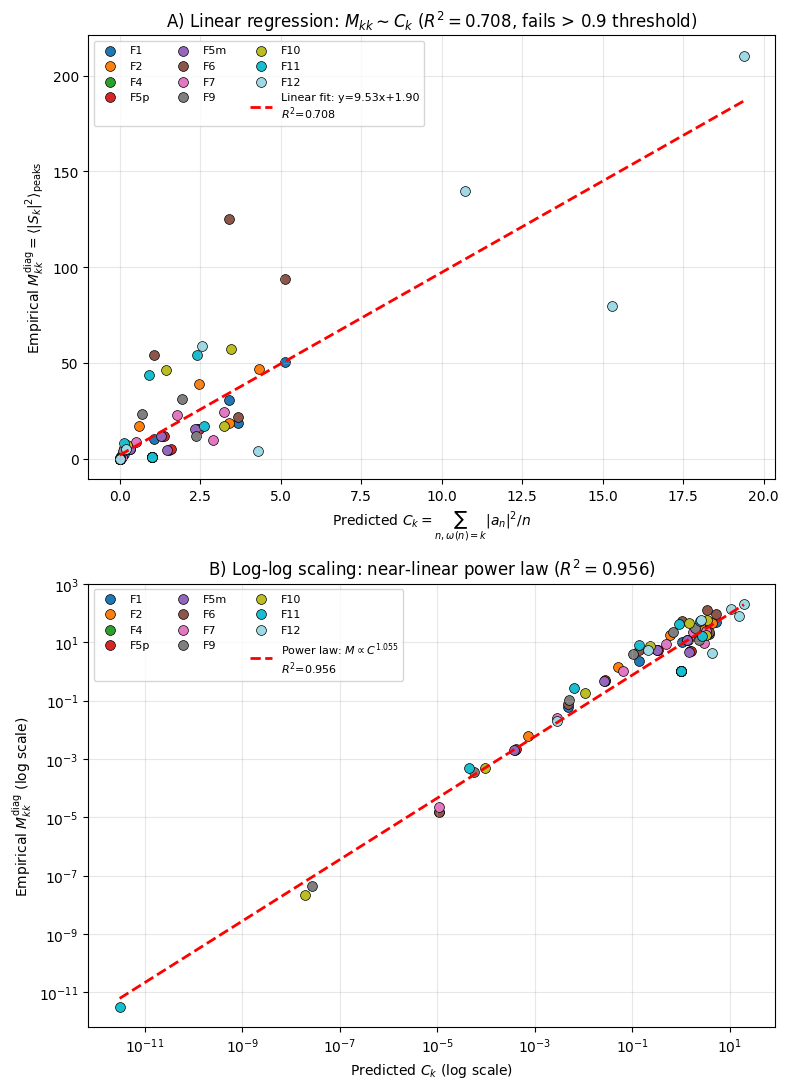

Saved figure.


In [29]:
# Final figure: a single scatter plot (log-log + linear inset would be 2 subfigures)
# Use 2 subfigures stacked: A) linear scatter, B) log-log scatter
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 11))

# Color by class
class_list = list(functions.keys())
colors = plt.cm.tab20(np.linspace(0, 1, len(class_list)))
class_to_color = {c: colors[i] for i, c in enumerate(class_list)}

# Subplot A: linear regression
for fn in class_list:
 sub_idx = [i for i, f in enumerate(fn_list) if f == fn]
 ax1.scatter(C_flat[sub_idx], M_flat[sub_idx], color=class_to_color[fn], label=fn, s=50, edgecolor='k', linewidth=0.5)
xx = np.linspace(C_flat.min(), C_flat.max(), 200)
ax1.plot(xx, slope*xx + intercept, 'r--', lw=2, label=f'Linear fit: y={slope:.2f}x+{intercept:.2f}\n$R^2$={r**2:.3f}')
ax1.set_xlabel('Predicted $C_k = \\sum_{n,\\omega(n)=k} |a_n|^2/n$')
ax1.set_ylabel('Empirical $M_{kk}^{\\rm diag} = \\langle |S_k|^2 \\rangle_{\\rm peaks}$')
ax1.set_title(f'A) Linear regression: $M_{{kk}} \\sim C_k$ ($R^2={r**2:.3f}$, fails > 0.9 threshold)')
ax1.legend(ncol=3, fontsize=8, loc='upper left')
ax1.grid(alpha=0.3)

# Subplot B: log-log
for fn in class_list:
 sub_idx = [i for i, f in enumerate(fn_list) if f == fn]
 Cs = C_flat[sub_idx]; Ms = M_flat[sub_idx]
 keep = (Cs > 1e-15) & (Ms > 1e-15)
 ax2.scatter(Cs[keep], Ms[keep], color=class_to_color[fn], label=fn, s=50, edgecolor='k', linewidth=0.5)
xx2 = np.logspace(np.log10(C_flat[mask].min()), np.log10(C_flat[mask].max()), 200)
ax2.plot(xx2, 10**intercept_log * xx2**slope_log, 'r--', lw=2, label=f'Power law: $M\\propto C^{{{slope_log:.3f}}}$\n$R^2$={r_log**2:.3f}')
ax2.set_xscale('log'); ax2.set_yscale('log')
ax2.set_xlabel('Predicted $C_k$ (log scale)')
ax2.set_ylabel('Empirical $M_{kk}^{\\rm diag}$ (log scale)')
ax2.set_title(f'B) Log-log scaling: near-linear power law ($R^2={r_log**2:.3f}$)')
ax2.legend(ncol=3, fontsize=8, loc='upper left')
ax2.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('Mkk_vs_Ck_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved figure.")

In [30]:
# Save artifacts
comp.to_csv('M_kk_vs_C_k_comparison.csv')
# Save C and M arrays
np.savez('Ck_Mkk_diag_results.npz', 
 classes=np.array(list(functions.keys())),
 C=C_df.values,
 M=emp_df.values)
print("Saved.")
import os
for f in ['F1_a.npy','F2_a.npy','F4_a.npy','F5p_a.npy','F5m_a.npy','F6_a.npy','F7_a.npy',
 'F9_lambda.npy','F10_lambda.npy','F11_lambda.npy','F12_a.npy','omega_n.npy','Omega_n.npy']:
 print(f, os.path.exists(f), os.path.getsize(f) if os.path.exists(f) else 0)

Saved.
F1_a.npy True 8000128
F2_a.npy True 16000128
F4_a.npy True 8000128
F5p_a.npy True 8000128
F5m_a.npy True 8000128
F6_a.npy True 8000128
F7_a.npy True 8000128
F9_lambda.npy True 8000128
F10_lambda.npy True 8000128
F11_lambda.npy True 8000128
F12_a.npy True 16000128
omega_n.npy True 4000128
Omega_n.npy True 4000128


In [31]:
from e14c.filesystem import write_file
from pathlib import Path
mem_path = Path('/workspace/621bf884-2390-4a4b-abee-b68ae27bef1f/.prompts/MEMORY.md')
content = mem_path.read_text()
new_content = """# Project Memory

## Instructions

Edit this file (`./.prompts/MEMORY.md`) to persist context, findings, and notes.
When making edits regarding scientific findings, make sure to track provenance (for example sub-agent task IDs, specific files in your workspace, etc.).

## Context

Current project: test whether empirical peak-averaged diagonal entries of the omega-stratified matrix, M_kk = E[|S_k|^2], are predictable from coefficient second moments C_k = sum_{n<=10^6, omega(n)=k} |a_n|^2/n across the 11 function classes present in `peaks_features_F1_F12_normalized_full.csv` (F1, F2, F4, F5p, F5m, F6, F7, F9, F10, F11, F12).

## Notes

- Provenance: analysis performed directly in notebook cells on 2026-05-09 in `/workspace/621bf884-2390-4a4b-abee-b68ae27bef1f`.
- Loaded empirical feature table `peaks_features_F1_F12_normalized_full.csv` (2200 rows, 200 peaks for each of 11 classes).
- Resolved local coefficient-file mapping issue: `a_n.npy` + `lambda_n.npy` in the workspace correspond to F11 (Sym^2 Delta), not F9; `a.npy`, `c.npy`, `rho0.npy`, `description.npy` correspond to F12.
- Generated/loaded coefficient arrays up to N=10^6 for all 11 classes: F1, F2, F4, F5p, F5m, F6, F7 generated locally; F9 and F10 generated with `cypari2`/PARI; F11 loaded from `lambda_n.npy`; F12 loaded from `a.npy`.
- Assumption used for F2: primitive quartic Dirichlet character mod 5 with chi(2)=i. Assumption used for F4/F5p/F5m: periodic Davenport-Heilbronn coefficient pattern c(1)=1, c(2)=kappa, c(3)=-kappa, c(4)=-1, c(5)=0 with validated kappa≈0.28408 and epsilon perturbations ±0.05.
- Computed omega(n) (distinct prime factors, not Omega(n)) for n<=10^6 and then C_k for k=0..7.
- Empirical diagonals M_kk computed as mean over 200 peaks of `abs_Sk^2` from the CSV.
- Main quantitative result: ordinary linear regression across all 88 class/stratum points gave slope 9.534624, intercept 1.898003, R^2=0.708303 (fails the stated >0.9 threshold).
- Secondary quantitative result: on log-log scale, log10(M_kk) vs log10(C_k) gave slope 1.0551 and R^2=0.956297, indicating strong proportional scaling in orders of magnitude but not a high-accuracy linear relation on the original scale.
- Consistent with prior project note from r25, k=7 entries are zero for mod-5-based families at N=10^6; excluding k=7 did not improve linear-fit R^2 materially (R^2≈0.6967).
- Saved artifacts: `M_kk_vs_C_k_comparison.csv`, `Ck_Mkk_diag_results.npz`, `Mkk_vs_Ck_scatter.png`, plus locally generated coefficient arrays (`F1_a.npy`, `F2_a.npy`, `F4_a.npy`, `F5p_a.npy`, `F5m_a.npy`, `F6_a.npy`, `F7_a.npy`, `F9_lambda.npy`, `F10_lambda.npy`, `F11_lambda.npy`, `F12_a.npy`, `omega_n.npy`, `Omega_n.npy`).
"""
write_file(str(mem_path), new_content)
print('memory updated')

memory updated
